# Langraph

In [35]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# This becomes the state of the graph.
class State(TypedDict):
    message: str


# A Node (just a function).
def chatbot(state: State):
    return {
        "message": "Hello from chatbot node"
    }


graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

result = graph.invoke({
    "message": "Hi"
})

print(result)

{'message': 'Hello from chatbot node'}


In [36]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    message: str


def node_1(state: State):
    return {
        "message": state["message"] + " -> node1"
    }


def node_2(state: State):
    return {
        "message": state["message"] + " -> node2"
    }

def node_3(state: State):
    return {
        "message": state["message"] + " -> node3"
    }


graph_builder = StateGraph(State)

graph_builder.add_node("node_1", node_1)
graph_builder.add_node("node_2", node_2)
graph_builder.add_node("node_3", node_3)

graph_builder.add_edge(START, "node_1")
graph_builder.add_edge("node_1", "node_2")
graph_builder.add_edge("node_2", "node_3")
graph_builder.add_edge("node_3", END)

graph = graph_builder.compile()

result = graph.invoke({
    "message": "start"
})

print(result)

{'message': 'start -> node1 -> node2 -> node3'}


In [37]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    messages: list


def node(state: State):
    return {
        "messages": ["Hello"]
    }


builder = StateGraph(State)

builder.add_node("node", node)

builder.add_edge(START, "node")
builder.add_edge("node", END)

graph = builder.compile()

result = graph.invoke({
    "messages": ["Hi"]
})

print(result)

{'messages': ['Hello']}


In [38]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


def node(state: State):
    return {
        "messages": ["Hello"]
    }


builder = StateGraph(State)

builder.add_node("node", node)

builder.add_edge(START, "node")
builder.add_edge("node", END)

graph = builder.compile()

result = graph.invoke({
    "messages": ["Hi"]
})

print(result)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='1390ab92-3ecf-4c01-9250-a0893183f624'), HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='946a217d-92c8-4ce5-9375-f07a5e1d324b')]}


In [39]:
!pip install langgraph langchain langchain-groq python-dotenv langchain-tavily langchain_openrouter

In [40]:
import os
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langchain_openrouter import ChatOpenRouter

load_dotenv()
openrouter_key = os.getenv("OPEN_ROUTER")
os.environ["OPENROUTER_API_KEY"] = openrouter_key

llm = ChatOpenRouter(
    model="gpt-oss-120b:free"
)


class State(TypedDict):
    messages: Annotated[list, add_messages]


def chatbot(state: State):

    response = llm.invoke(state["messages"])

    return {
        "messages": [response]
    }


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

result = graph.invoke({
    "messages": [
        ("human", "Hi")
    ]
})

print(result)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='a53f107a-6b90-4caa-b55d-93c2f827bb59'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'Need to respond friendly.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Need to respond friendly.'}]}, response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780921172-S6LE93JmcxUgS4ssFP8u', 'created': 1780921172, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019ea72c-822b-7fa0-8eb4-b527530a2dc5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 24, 'total_tokens': 92, 'input_token_details': {'cache_read': 64, 'cache_creation': 0}, 'output_token_details': {'reasoning': 7}})]}


In [41]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain_core.messages import HumanMessage

load_dotenv()

openrouter_key = os.getenv("GROQ")
os.environ["GROQ_API_KEY"] = openrouter_key

class State(TypedDict):
    messages: Annotated[list, add_messages]


llm = ChatOpenRouter(
    model="gpt-oss-120b:free"
)


def chatbot(state: State):

    response = llm.invoke(state["messages"])

    return {
        "messages": [response]
    }


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()


conversation = []

while True:

    user_input = input("You: ")

    if user_input == "exit":
        break

    conversation.append(
        HumanMessage(content=user_input)
    )

    result = graph.invoke({
        "messages": conversation
    })

    ai_message = result["messages"][-1]

    print("AI:", ai_message.content)

    conversation.append(ai_message)

You: hi i ma ms22
AI: Hello! 👋 Nice to meet you, ms22. How can I help you today?
You: whats my name 
AI: Your name is **ms22**. Let me know if there’s anything else you’d like to talk about!
You: exit


In [42]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver

from langchain_core.messages import HumanMessage

from langchain_groq import ChatGroq


load_dotenv()


class State(TypedDict):
    messages: Annotated[list, add_messages]

memory = MemorySaver()


def chatbot(state: State):

    response = llm.invoke(state["messages"])

    return {
        "messages": [response]
    }


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)


graph = builder.compile(
    checkpointer=memory
)


config = {
    "configurable": {
        "thread_id": "user_1"
    }
}


while True:

    user_input = input("You: ")

    if user_input == "exit":
        break

    result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config
    )

    print(
        "AI:",
        result["messages"][-1].content
    )

You: hi i am  ms22
AI: Hello! 👋 Nice to meet you, ms22. How can I assist you today?
You: whats my name
AI: Your name is **ms22**. 😊
You: exit


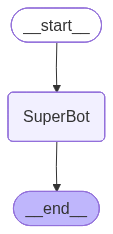

In [43]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

graph=StateGraph(State)

graph.add_node("SuperBot",superbot)
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [45]:
config = {"configurable": {"thread_id": "1"}}
graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='d8bfbd5e-f0f0-427c-a1e9-bbd81bbde1ae'),
  AIMessage(content='Hello Krish! 👋 Great to meet you.  \n\nCricket has a way of bringing people together—whether you’re a fan of Test marathon sessions, the excitement of ODIs, or the high‑octane action of T20.  \n\n- Do you have a favorite format?  \n- Which team or player do you root for?  \n- Any memorable matches that still give you chills?\n\nLooking forward to hearing more about your cricket passion! 🏏✨', additional_kwargs={'reasoning_content': 'We need to respond friendly, maybe ask about cricket preferences.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to respond friendly, maybe ask about cricket preferences.'}]}, response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780921308-zvEkoDddx3ifJfLhRelg', 'created': 1780921308, 'object': 'chat.com

In [48]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Krish! 👋 It’s always a pleasure to meet someone who loves cricket.  \n\n### Let’s get the conversation rolling\n| Question | Your Thoughts |\n|----------|----------------|\n| **1️⃣ Favorite team** | Which side do you cheer for—India, England, Australia, or maybe a franchise team in the IPL, BBL, CPL, etc.? |\n| **2️⃣ Idol on the field** | A batting maestro, a bowling wizard, or an all‑rounder who inspires you? |\n| **3️⃣ Most memorable match** | A nail‑biting finish, a historic comeback, or perhaps a game you played yourself? |\n| **4️⃣ Your cricket involvement** | Are you mainly a fan, a regular player at the park, a coach, or do you follow the stats and analysis? |\n| **5️⃣ Anything else?** | Any upcoming tournament you’re excited about, or a cricket‑related question you’ve been pondering? |\n\nFeel free to answer any or all of the above, or just share whatever cricket stories are on your mind. I’m all ears (and a lot of cricket facts

In [50]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='59f831a0-323c-4534-bfb9-0b37032beb95'), AIMessage(content='Hello Krish! 👋 Nice to meet you.  \n\nIt’s great to hear you’re a cricket fan—there’s always something exciting happening on the pitch. Do you have a favorite team or player? Are you more into watching the matches, playing the game yourself, or maybe both? Let’s chat about all things cricket! 🏏✨', additional_kwargs={'reasoning_content': 'We need to respond friendly, ask about cricket etc.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to respond friendly, ask about cricket etc.'}]}, response_metadata={'model_name': 'openai/gpt-oss-120b:free', 'id': 'gen-1780921342-Ywc1N5ubuDS1ktBuwmgU', 'created': 1780921342, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019ea72f-1923-7fd3-b3f1-6841

In [57]:
import asyncio

async def main():

    config = {
        "configurable": {
            "thread_id": "5"
        }
    }

    async for event in graph_builder.astream_events(
        {
            "messages": [
                "Hi My name is Krish and I like to play cricket"
            ]
        },
        config,
        version="v2"
    ):
        print(event)


await main()

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ea733-6bf5-7fc1-a364-06785ab85678', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='3e6f463a-43c7-49c5-932f-8dc285ae428e'), AIMessage(content='Hey Krish! Great to meet you.  \n\nCricket’s such a fun sport—whether you’re into batting, bowling, or just cheering from the stands.  \n\nDo you play yourself, or are you more of a fan? If you play, what’s your favorite format (Test, ODI, T20, or maybe even a local league)? And if you’re a fan, which team or player gets you the most excited? 🎯🏏\n\nLooking forward to hearing all about your cricket adventures!', additional_kwargs={'reasoning_content': 'We need to respond friendly, 

In [59]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from langgraph.types import interrupt
from langgraph.types import Command

from langchain_core.tools import tool

from langchain_groq import ChatGroq


load_dotenv()


class State(TypedDict):
    messages: Annotated[list, add_messages]


llm = ChatOpenRouter(
    model="gpt-oss-120b:free"
)


@tool
def ask_human(question: str) -> str:
    """
    Ask human for help.
    """

    response = interrupt(
        {
            "question": question
        }
    )

    return response["data"]


tools = [ask_human]

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "chatbot"
)

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge(
    "tools",
    "chatbot"
)


memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory
)


config = {
    "configurable": {
        "thread_id": "1"
    }
}


events = graph.stream(
    {
        "messages": [
            (
                "user",
                "I need expert advice for building AI agents"
            )
        ]
    },
    config=config,
    stream_mode="values"
)


for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need expert advice for building AI agents
================================== Ai Message ==================================

Below is a comprehensive, step‑by‑step playbook for designing, building, and deploying **autonomous AI agents** (often called “AI copilots,” “agents,” or “tool‑using LLMs”). It covers everything from high‑level architecture to concrete implementation patterns, safety checks, and maintenance practices.

---

## 1️⃣ Define the Agent’s **Scope & Goals**

| Question | Why it matters | Example answer |
|----------|----------------|----------------|
| **What problem is the agent solving?** | Determines required knowledge, tools, and metrics. | “Schedule meetings and draft follow‑up emails for sales reps.” |
| **Who are the primary users?** | Shapes UX, language style, and compliance needs. | “Internal sales team, tech‑savvy, need GDPR compliance.” |
| **What is the success metric?** | Gi

In [60]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END


class State(TypedDict):
    input: str


def router(state: State):

    user_input = state["input"].lower()

    if "math" in user_input:
        return "math_node"

    return "chatbot"


def chatbot(state: State):

    return {
        "input": "Normal chatbot response"
    }


def math_node(state: State):

    return {
        "input": "Math specialist response"
    }

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("math_node", math_node)
builder.add_edge(
    START,
    "router"
)

builder.add_node(
    "router",
    lambda state: state
)

builder.add_conditional_edges(
    "router",
    router
)

builder.add_edge(
    "chatbot",
    END
)

builder.add_edge(
    "math_node",
    END
)

graph = builder.compile()
result = graph.invoke({
    "input": "I need math help"
})


print(result)

{'input': 'Math specialist response'}
